In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib as mpl

## Algorítimo:

Corrida 7 usada de exemplo.

### 1. Ler:

In [2]:
corrida7_bruto = pd.read_csv('experimental_data/corrida7.txt', sep='\t')
display(corrida7_bruto.head(25))

,Posição_Angular(graus),Intensidade_rel_(%)
0,"0,000","0,001"
1,"0,000","17,155"
2,"0,000","17,167"
3,"0,000","17,170"
4,"0,000","17,226"
5,"0,000","17,180"
6,"0,000","17,210"
7,"0,000","17,211"
8,"0,000","17,179"
9,"0,000","17,182"


In [3]:
# Informações gerais
print(f"Corrida - Dados brutos:\n{corrida7_bruto.info()}")

# Tipos das colunas
print(f"Tipos das colunas:\n{corrida7_bruto.dtypes}")

# Estatísticas descritivas
print(f"Estatísticas descritivas:\n{corrida7_bruto.describe()}")

# Quantidade de valores nulos
print(f"Quantidade de valores nulos:\n{corrida7_bruto.isnull().sum()}")

# Dimensão do dataframe
print(f"Dimensão do dataframe:\n{corrida7_bruto.shape}")

# Nomes das colunas
print(f"Nomes das colunas:\n{corrida7_bruto.columns}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Posição_Angular(graus)  1200 non-null   object
 1   Intensidade_rel_(%)     1200 non-null   object
dtypes: object(2)
memory usage: 18.9+ KB
Corrida - Dados brutos:
None
Tipos das colunas:
Posição_Angular(graus)    object
Intensidade_rel_(%)       object
dtype: object
Estatísticas descritivas:
       Posição_Angular(graus) Intensidade_rel_(%)
count                    1200                1200
unique                    254                 923
top                    95,146              15,301
freq                      258                   5
Quantidade de valores nulos:
Posição_Angular(graus)    0
Intensidade_rel_(%)       0
dtype: int64
Dimensão do dataframe:
(1200, 2)
Nomes das colunas:
Index(['Posição_Angular(graus)', 'Intensidade_rel_(%)'], dtype='object')


### 2. Limpar:

In [4]:
corrida7_limpo = corrida7_bruto.copy()
corrida7_limpo['Posição_Angular(graus)'] = corrida7_bruto['Posição_Angular(graus)'].str.replace(",", ".", case=False, regex=False)
corrida7_limpo['Intensidade_rel_(%)'] = corrida7_bruto['Intensidade_rel_(%)'].str.replace(",", ".", case=False, regex=False)

In [5]:
print(corrida7_limpo.dtypes)

Posição_Angular(graus)    object
Intensidade_rel_(%)       object
dtype: object


In [6]:
corrida7_limpo['Posição_Angular(graus)'] = pd.to_numeric(corrida7_limpo['Posição_Angular(graus)'])
corrida7_limpo['Intensidade_rel_(%)'] = pd.to_numeric(corrida7_limpo['Intensidade_rel_(%)'])

In [7]:
print(corrida7_limpo.dtypes)

Posição_Angular(graus)    float64
Intensidade_rel_(%)       float64
dtype: object


### 3. Visualizar:

In [8]:
def visualizar_dados(corrida):
    plt.figure(figsize=(17, 6))
    plt.scatter(corrida["Posição_Angular(graus)"], corrida["Intensidade_rel_(%)"], color="blue", label="Dados experimentais",marker='o',s=8)
    plt.xlabel("Posição angular (°)")
    plt.ylabel("Intensidade rel.")
    plt.title("Intensidade relativa vs Posição angular")
    plt.grid()
    plt.show()
    return None

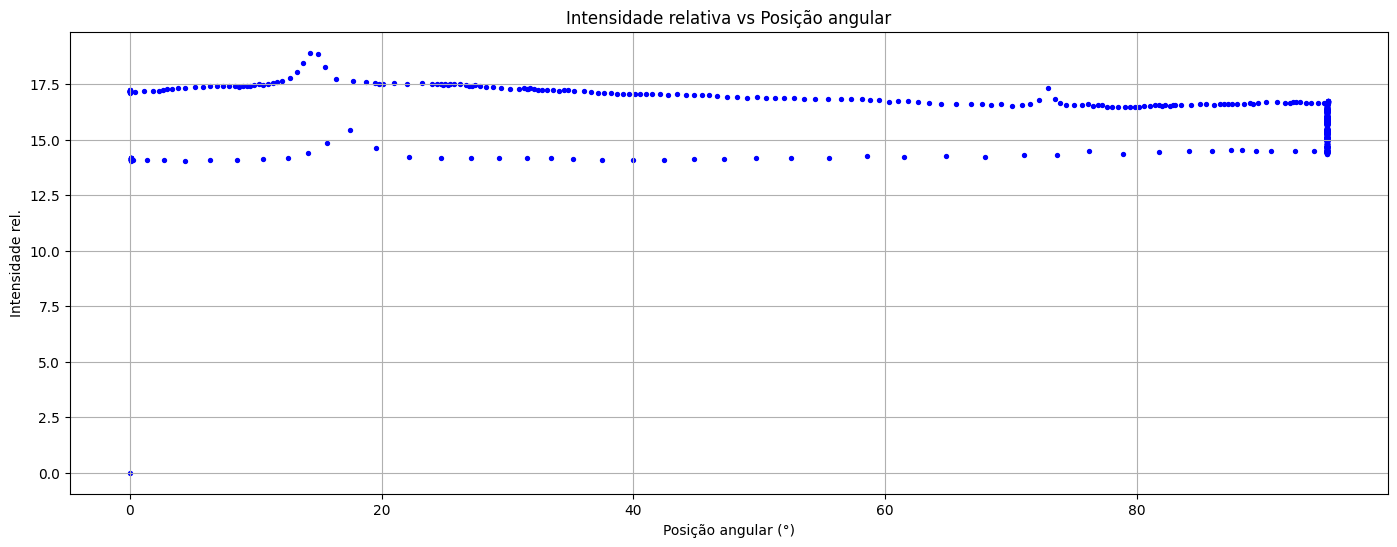

In [9]:
visualizar_dados(corrida7_limpo)

### 4. Escolher domínio útil:

In [10]:
def dominio(corrida, 
            angulo_min=0, 
            angulo_max=360, 
            intensidade_min=0,
            intensidade_max=100,
            visualizar=True):
    corrida_filtrada = corrida.copy()
    corrida_filtrada = corrida_filtrada[corrida_filtrada['Posição_Angular(graus)'] >= angulo_min]
    corrida_filtrada = corrida_filtrada[corrida_filtrada['Posição_Angular(graus)'] <= angulo_max]
    corrida_filtrada = corrida_filtrada[corrida_filtrada['Intensidade_rel_(%)'] >= intensidade_min]
    corrida_filtrada = corrida_filtrada[corrida_filtrada['Intensidade_rel_(%)'] <= intensidade_max]
    if visualizar:
        plt.figure(figsize=(17, 6))
        plt.scatter(corrida_filtrada["Posição_Angular(graus)"], corrida_filtrada["Intensidade_rel_(%)"], color="blue", label="Dados experimentais",marker='o',s=8)
        plt.xlabel("Posição angular (°)")
        plt.ylabel("Intensidade rel.")
        plt.title("Intensidade relativa vs Posição angular")
        plt.grid()
        plt.show()
    return corrida_filtrada

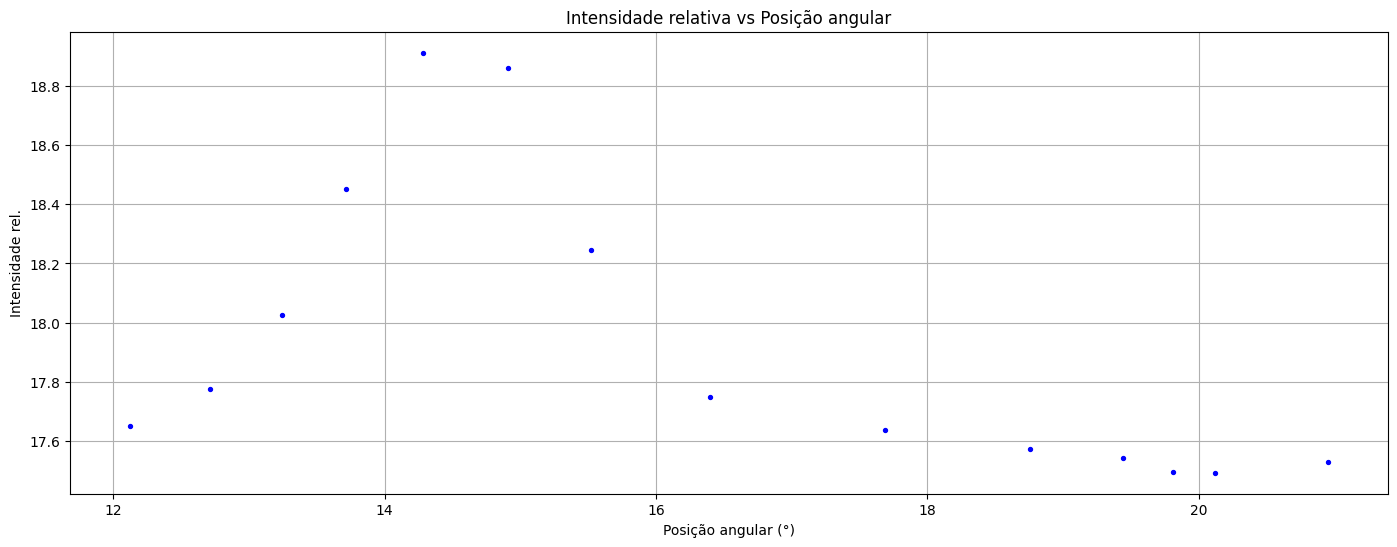

In [11]:
corrida7_filtrada = dominio(corrida7_limpo, angulo_min=12, angulo_max=21, intensidade_min=16)

### 5. Transformação de eixo:

In [12]:
def theta_para_lambda(theta, A=13900, B=1.689):
    theta_rad = np.deg2rad(theta)
    n = ( ( 2*np.sin(1.3439-theta_rad)/(3**0.5) + (1/2) ) ** 2 + (3/4) ) ** 0.5
    lambida = ( A / (n - B) ) ** 0.5
    return lambida

def transformacao_de_eixo(corrida, visualizar=True):
    corrida_transformada = corrida.copy()
    corrida_transformada['Comprimento_de_onda(nm)'] = theta_para_lambda(corrida_transformada['Posição_Angular(graus)'])
    if visualizar:
        plt.figure(figsize=(17, 6))
        plt.scatter(corrida_transformada["Comprimento_de_onda(nm)"], corrida_transformada["Intensidade_rel_(%)"], color="blue", label="Dados experimentais",marker='o',s=8)
        plt.xlabel("Comprimento de onda (nm)")
        plt.ylabel("Intensidade rel.")
        plt.title("Intensidade relativa vs Comprimento de onda")
        plt.grid()
        plt.show()
    return corrida_transformada

In [13]:
corrida7_transformada = transformacao_de_eixo(corrida7_filtrada, visualizar=False)

### 6. Impor Intensidade = 0 como mínimo da curva:

In [14]:
corrida7_final = corrida7_transformada.copy()
corrida7_final["Intensidade_rel_(%)"] += -corrida7_transformada["Intensidade_rel_(%)"].min()

### Visualizar Lei de Plank experimental:

In [15]:
def lei_de_plank(corrida, spline=False, lim_inferior=None, lim_superior=None):

    x = corrida["Comprimento_de_onda(nm)"]
    y = np.log(corrida["Intensidade_rel_(%)"] + 1e-10)

    plt.figure(figsize=(17, 6))

    # gráfico original
    plt.plot(x, y, color="blue", label="Dados")

    # spline opcional
    if spline:

        # garante ordenação
        ordem = np.argsort(x)
        x_sorted = np.array(x)[ordem]
        y_sorted = np.array(y)[ordem]

        # spline cúbica
        cs = CubicSpline(x_sorted, y_sorted)

        # pontos interpolados
        x_fit = np.linspace(x_sorted.min(), x_sorted.max(), 1000)
        y_fit = cs(x_fit)

        plt.plot(
            x_fit,
            y_fit,
            color="blue",
            linewidth=2,
            label="Spline cúbica"
        )

    plt.xlabel("Comprimento de onda (nm)")
    plt.ylabel("Intensidade rel.")
    plt.title("Intensidade relativa vs Comprimento de onda")
    plt.grid()
    plt.xlim(lim_inferior, lim_superior)
    plt.legend()
    plt.show()

    return None

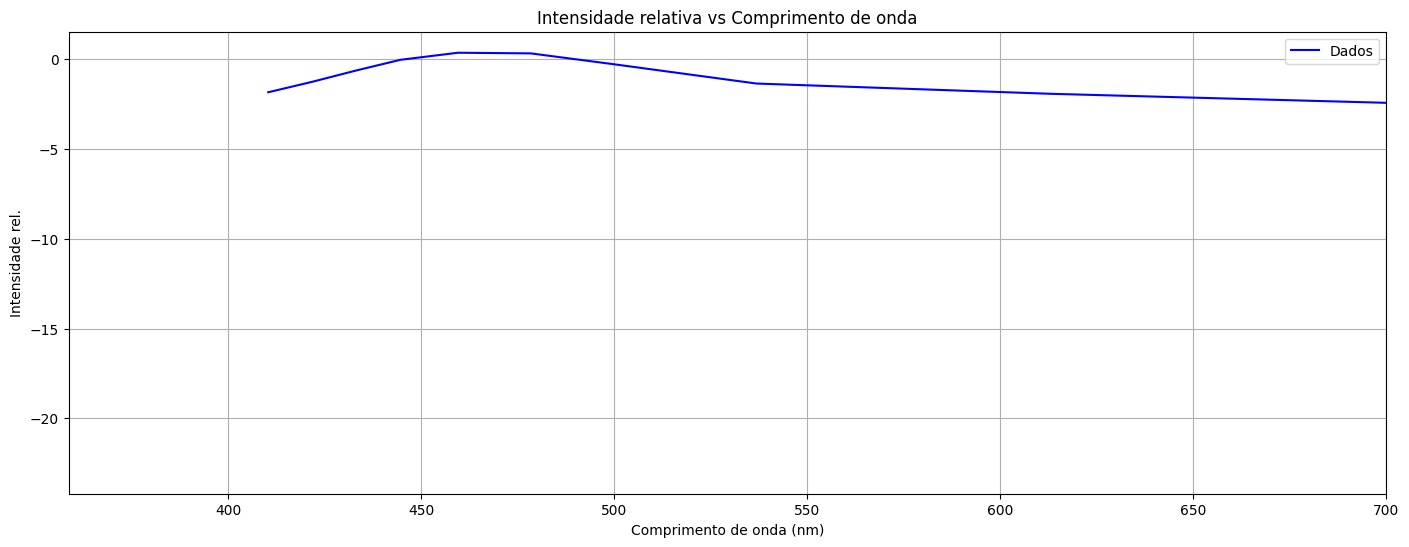

In [16]:
lei_de_plank(corrida7_final, lim_superior=700)

## Corrida 8:

In [17]:
corrida8_bruto = pd.read_csv('experimental_data/corrida8.txt', sep='\t')
display(corrida8_bruto.head(25))

,Posição_Angular(graus),Intensidade_rel_(%)
0,"0,000","13,954"
1,"0,000","13,974"
2,"0,000","13,997"
3,"0,000","13,917"
4,"0,000","13,926"
5,"0,000","13,969"
6,"0,000","13,930"
7,"0,000","13,910"
8,"0,000","13,896"
9,"0,000","13,873"


In [18]:
corrida8_limpo = corrida8_bruto.copy()
corrida8_limpo['Posição_Angular(graus)'] = corrida8_bruto['Posição_Angular(graus)'].str.replace(",", ".", case=False, regex=False)
corrida8_limpo['Intensidade_rel_(%)'] = corrida8_bruto['Intensidade_rel_(%)'].str.replace(",", ".", case=False, regex=False)

In [19]:
corrida8_limpo['Posição_Angular(graus)'] = pd.to_numeric(corrida8_limpo['Posição_Angular(graus)'])
corrida8_limpo['Intensidade_rel_(%)'] = pd.to_numeric(corrida8_limpo['Intensidade_rel_(%)'])

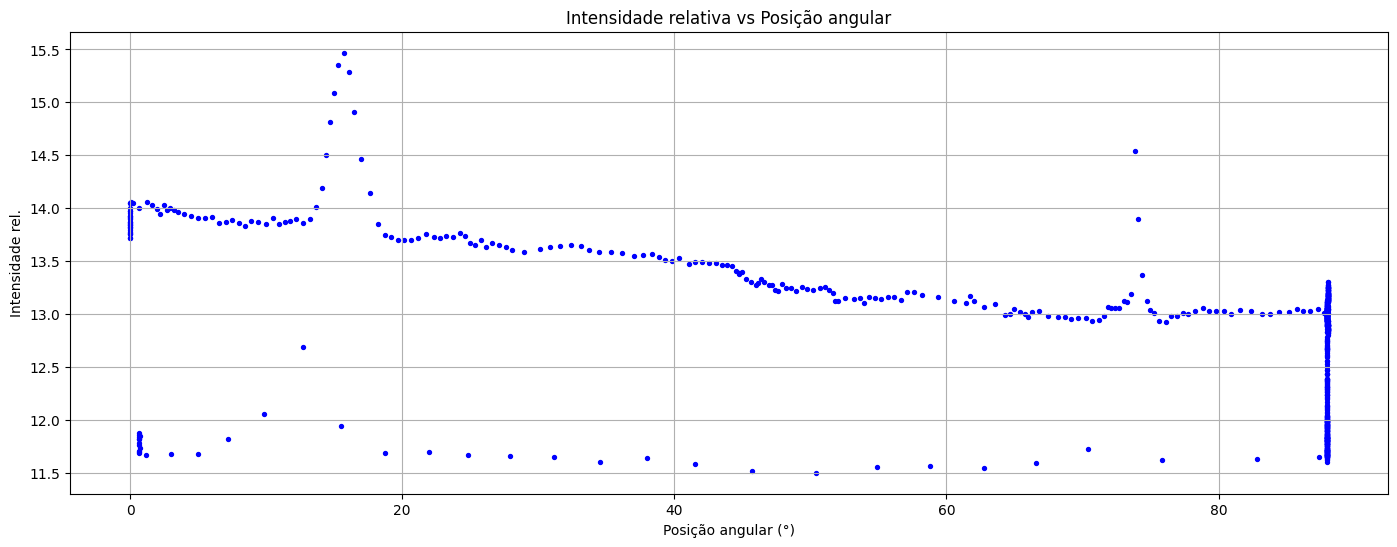

In [20]:
visualizar_dados(corrida8_limpo)

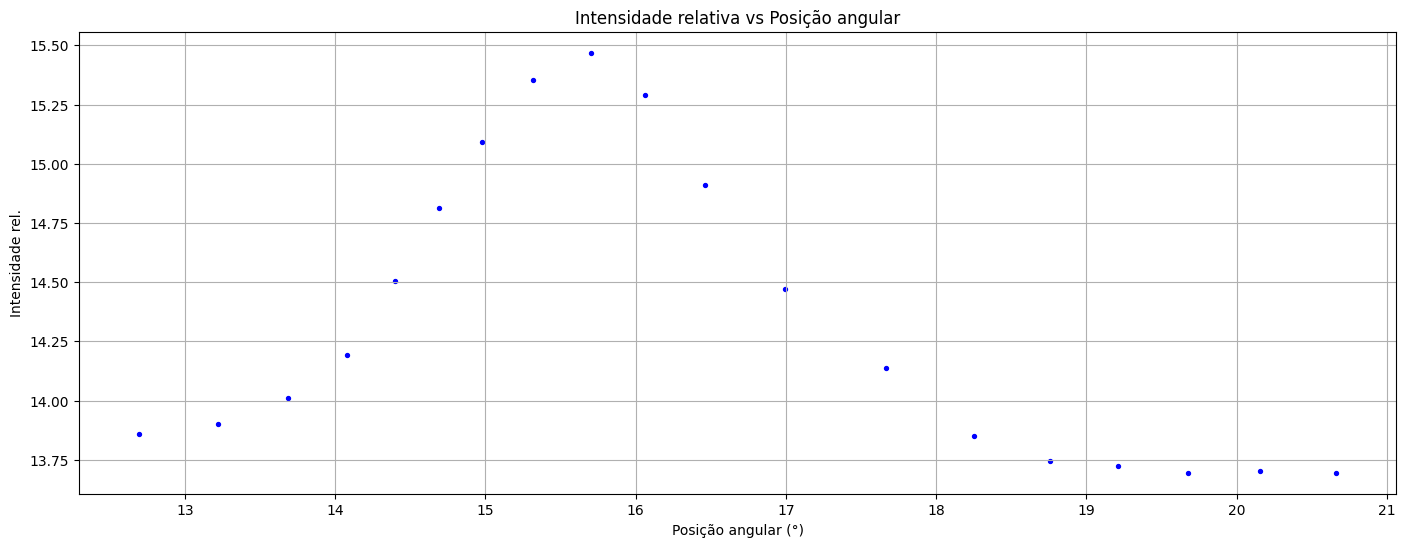

In [21]:
corrida8_filtrada = dominio(corrida8_limpo, angulo_min=12.5, angulo_max=21, intensidade_min=13)

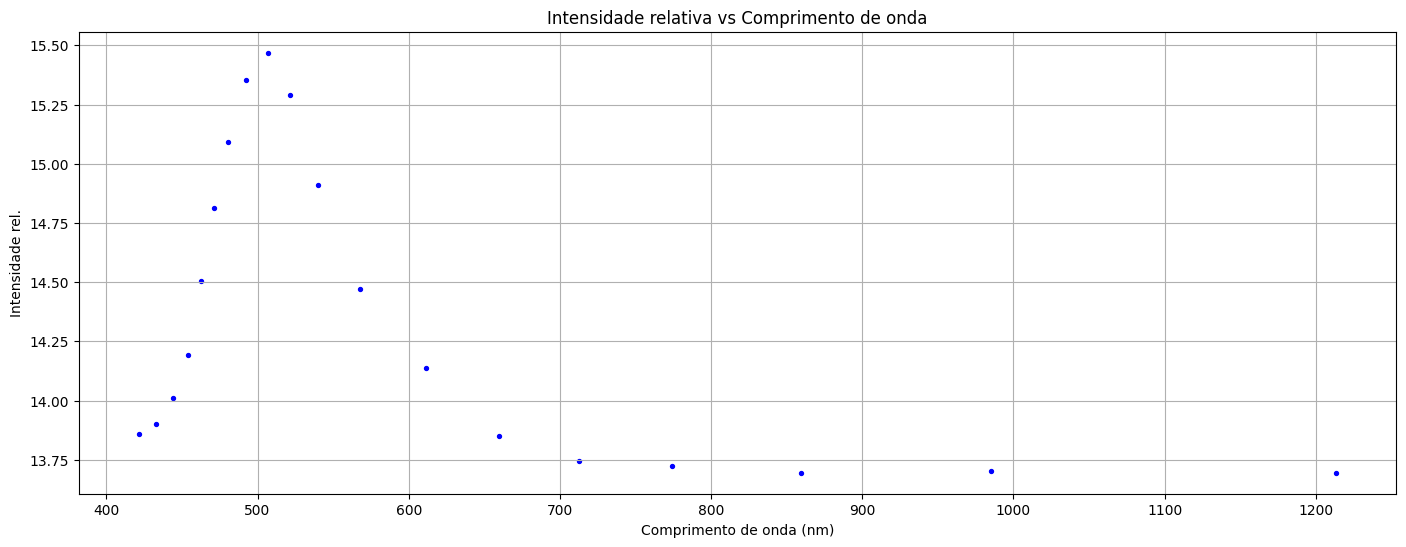

In [22]:
corrida8_transformada = transformacao_de_eixo(corrida8_filtrada)

In [23]:
corrida8_final = corrida8_transformada.copy()
corrida8_final["Intensidade_rel_(%)"] += -corrida8_transformada["Intensidade_rel_(%)"].min()

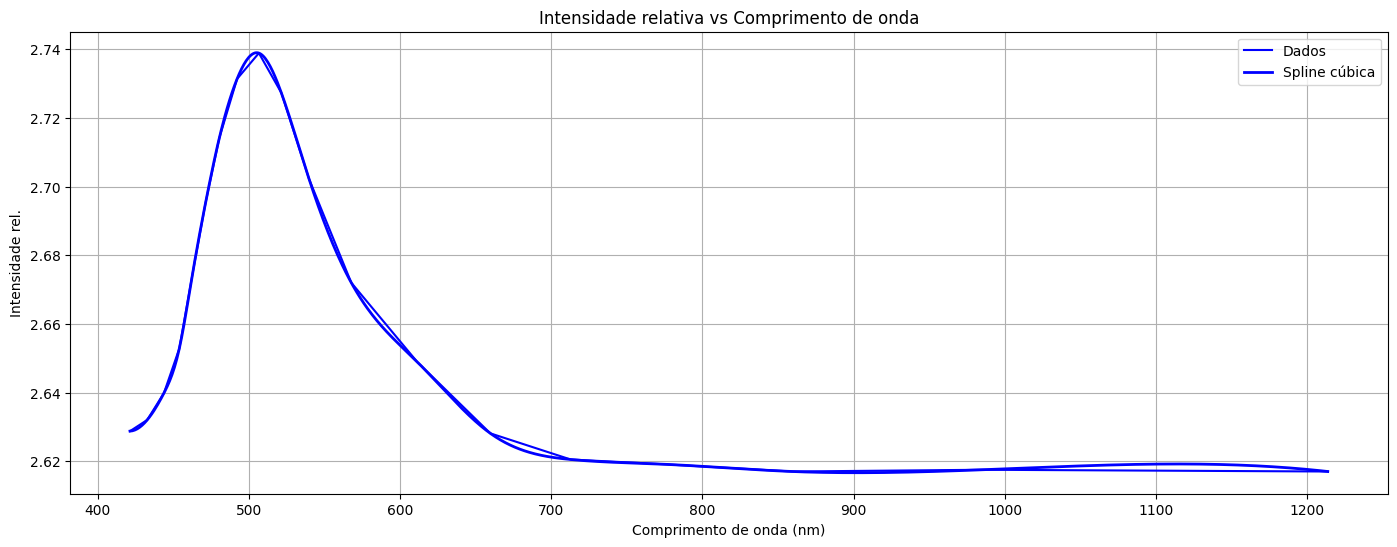

In [24]:
lei_de_plank(corrida8_transformada, spline=True)

## Comparação de Curvas:

In [ ]:
def lei_de_plank_varias(corridas, spline=False, lim_inferior=None, lim_superior=None, rm_offset=False, normalizar=False, save_fig=False, nome_fig="lei_de_plank.png"):

    plt.figure(figsize=(17, 6))

    # garante que entrada única também funcione
    if not isinstance(corridas, list):
        corridas = [corridas]

    cores = plt.cm.viridis(np.linspace(0, 1, len(corridas)))

    for i, corrida in enumerate(corridas):

        x = corrida["Comprimento_de_onda(nm)"]
        y = corrida["Intensidade_rel_(%)"]

        if rm_offset:
            y = y - y.min()  # desloca para mínimo zero

        if normalizar:
            y = y / y.max()  # escala para máximo 1

        cor = cores[i]

        # curva original
        plt.plot(
            x,
            y,
            color=cor,
            alpha=1,
            label=f"Corrida {i+1}"
        )

        # spline opcional
        if spline:

            ordem = np.argsort(x)

            x_sorted = np.array(x)[ordem]
            y_sorted = np.array(y)[ordem]

            cs = CubicSpline(x_sorted, y_sorted)

            x_fit = np.linspace(
                x_sorted.min(),
                x_sorted.max(),
                1000
            )

            y_fit = cs(x_fit)

            plt.plot(
                x_fit,
                y_fit,
                color=cor,
                linewidth=2
            )

    plt.xlabel("Comprimento de onda (nm)", fontsize=18)
    plt.ylabel("Intensidade", fontsize=18)
    plt.title("Intensidade vs Comprimento de onda", fontsize=20)
    plt.xlim(lim_inferior, lim_superior)  # ajuste conforme necessário
    #plt.grid()
    plt.yticks([])  # remove ticks do eixo y para melhor visualização
    plt.legend(fontsize=15)
    plt.tight_layout()
    if save_fig:
        plt.savefig(f"figs/{nome_fig}", dpi=300, bbox_inches='tight')
    plt.show()

    return None

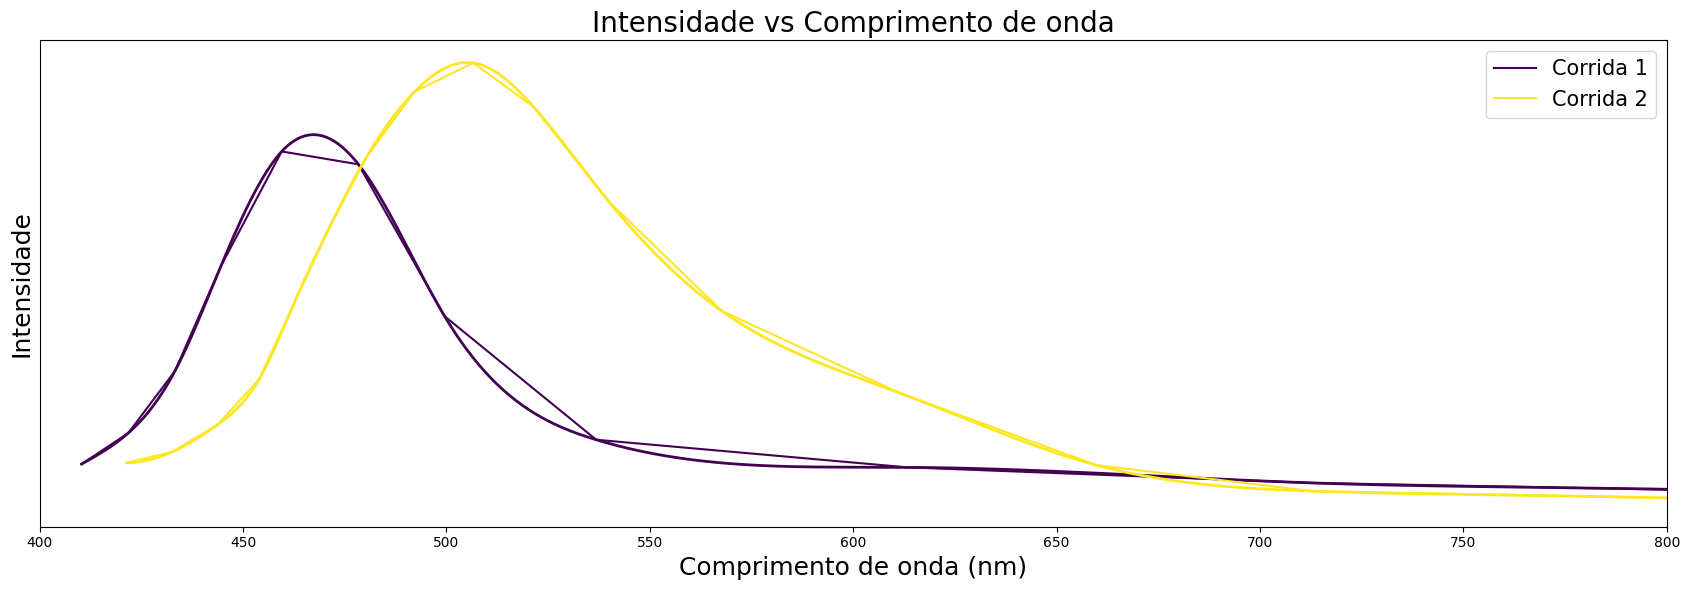

In [26]:
lei_de_plank_varias([corrida7_final, corrida8_final], spline=True, lim_inferior=400, lim_superior=800)

## Corrida 9:

,Posição_Angular(graus),Intensidade_rel_(%)
0,"-0,002","11,736"
1,"-0,003","11,748"
2,"0,000","11,759"
3,"0,002","11,761"
4,"0,005","11,794"
5,"0,005","11,738"
6,"0,006","11,743"
7,"0,006","11,698"
8,"0,006","11,748"
9,"0,006","11,714"


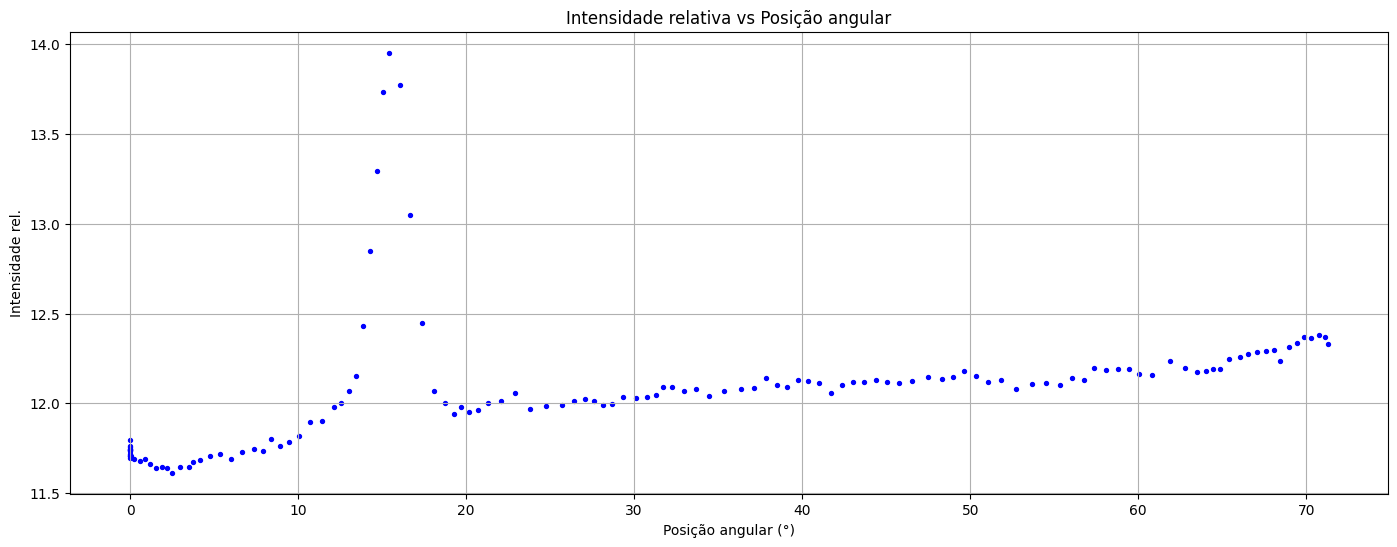

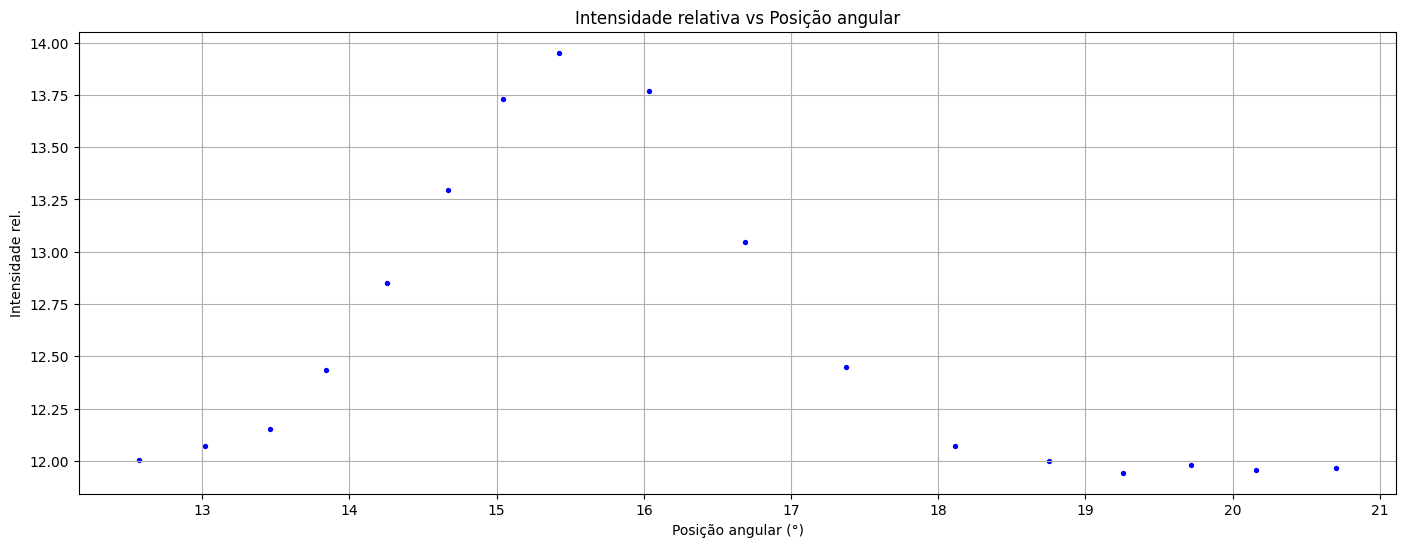

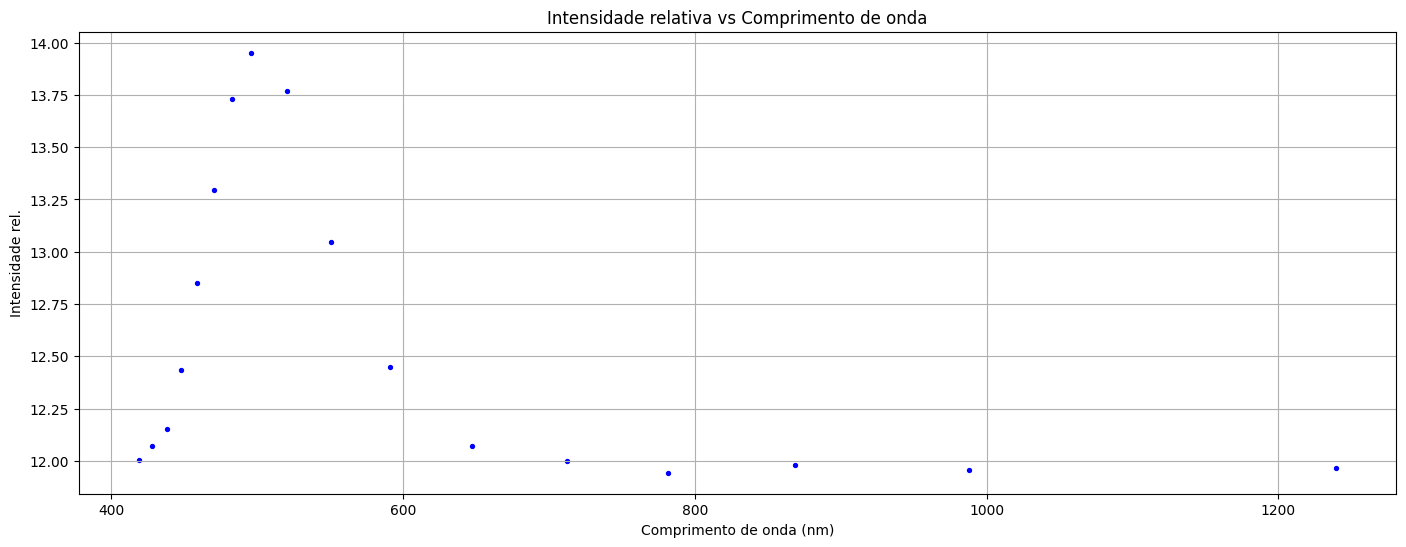

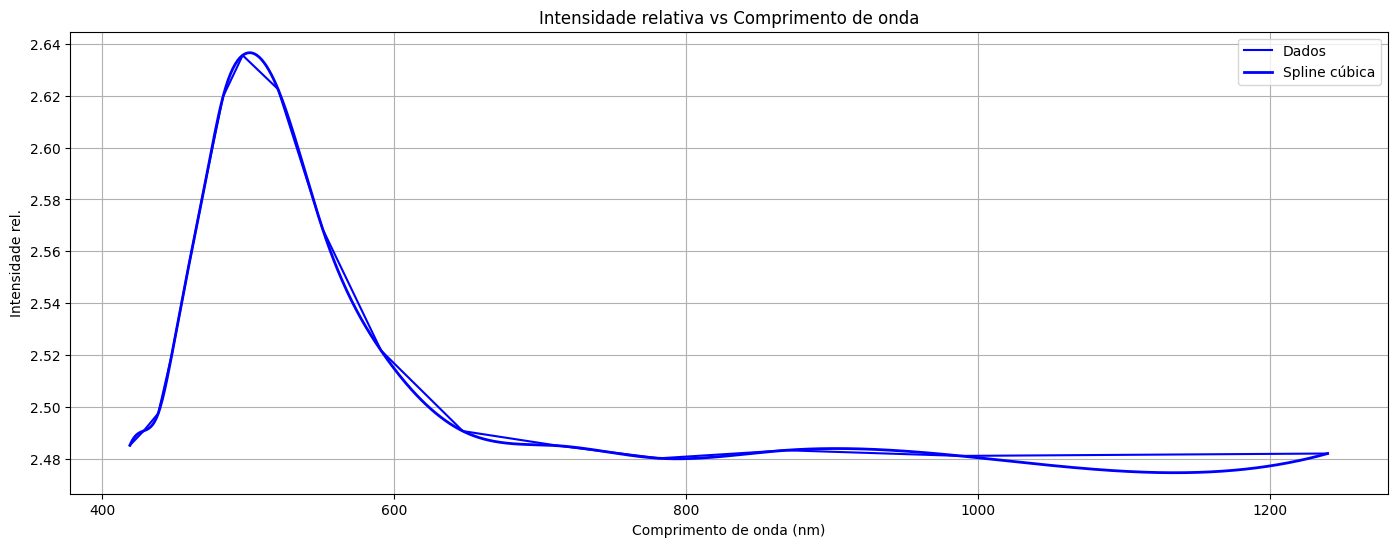

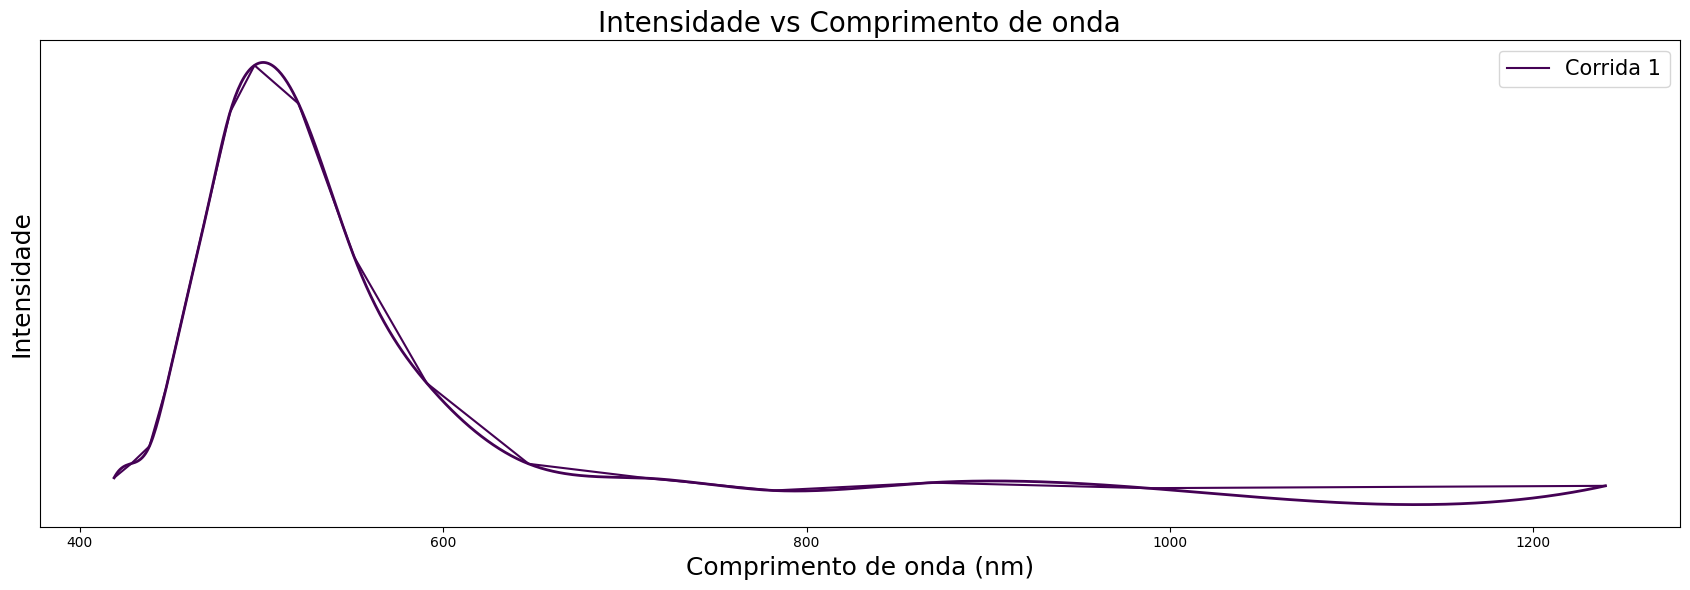

In [27]:
corrida9_bruto = pd.read_csv('experimental_data/corrida9.txt', sep='\t')
display(corrida9_bruto.head(25))

corrida9_bruto = corrida9_bruto[corrida9_bruto.index < 133]

corrida9_limpo = corrida9_bruto.copy()
corrida9_limpo['Posição_Angular(graus)'] = corrida9_bruto['Posição_Angular(graus)'].str.replace(",", ".", case=False, regex=False)
corrida9_limpo['Intensidade_rel_(%)'] = corrida9_bruto['Intensidade_rel_(%)'].str.replace(",", ".", case=False, regex=False)

corrida9_limpo['Posição_Angular(graus)'] = pd.to_numeric(corrida9_limpo['Posição_Angular(graus)'])
corrida9_limpo['Intensidade_rel_(%)'] = pd.to_numeric(corrida9_limpo['Intensidade_rel_(%)'])

visualizar_dados(corrida9_limpo)

corrida9_filtrada = dominio(corrida9_limpo, angulo_min=12.5, angulo_max=21)

corrida9_transformada = transformacao_de_eixo(corrida9_filtrada)

corrida9_final = corrida9_transformada.copy()
corrida9_final["Intensidade_rel_(%)"] += -corrida9_transformada["Intensidade_rel_(%)"].min()

lei_de_plank(corrida9_transformada, spline=True)

lei_de_plank_varias([corrida9_final], spline=True)# lim_inferior=400, lim_superior=800)

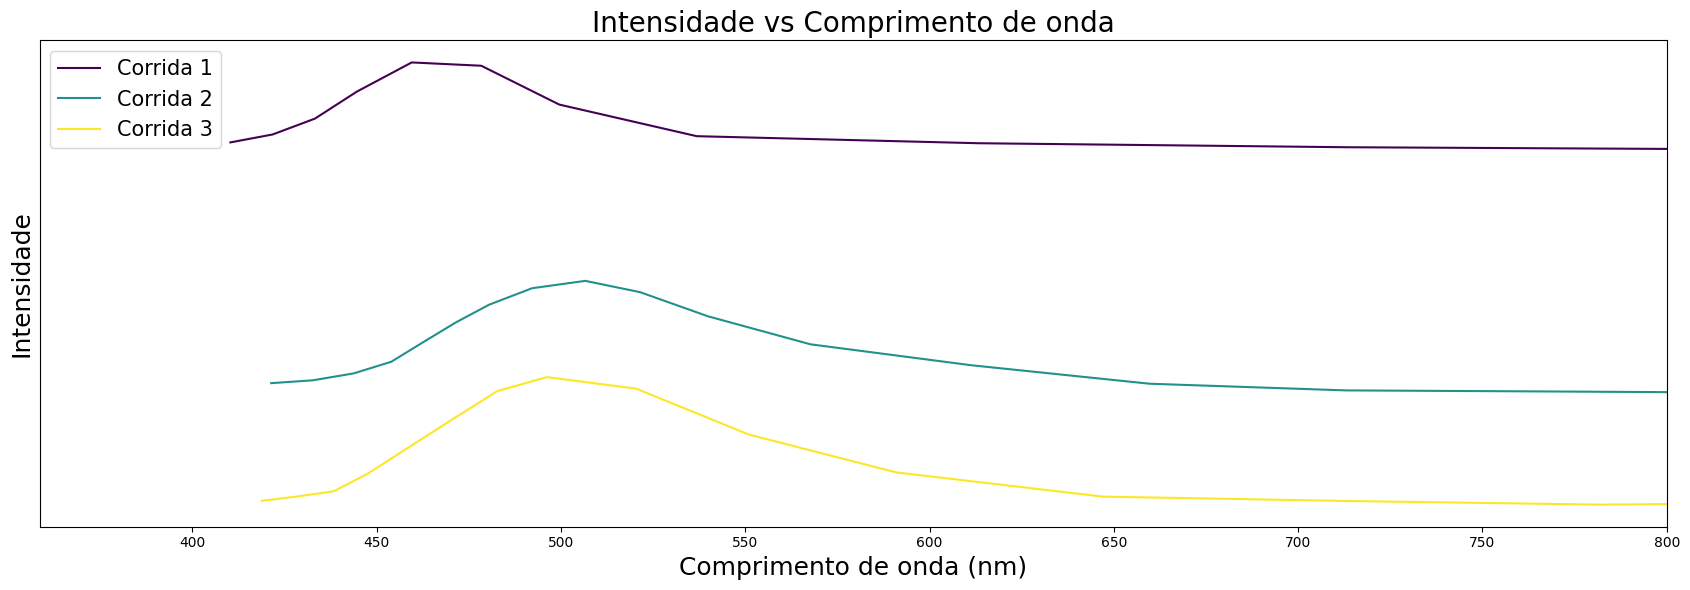

In [28]:
lei_de_plank_varias([corrida7_transformada, corrida8_transformada, corrida9_transformada], lim_superior=800)

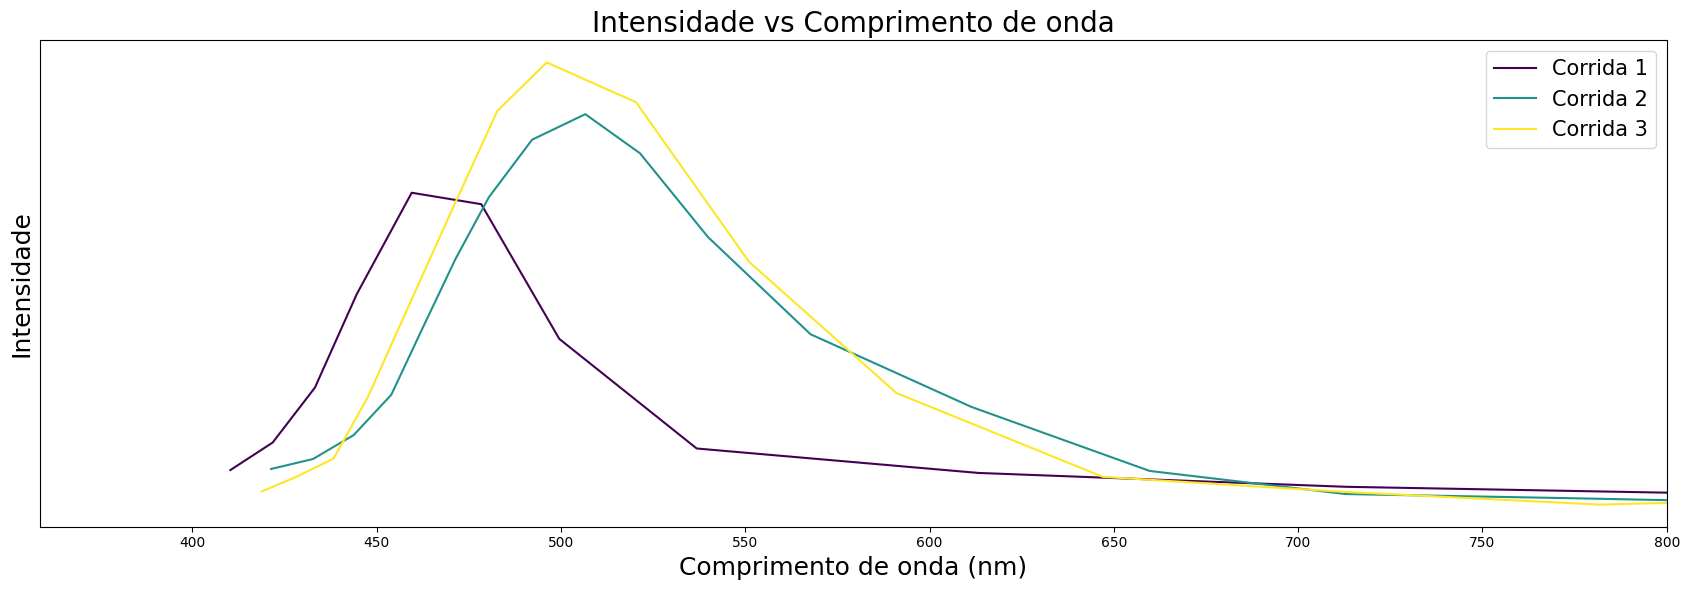

In [29]:
lei_de_plank_varias([corrida7_final, corrida8_final, corrida9_final], lim_superior=800)

In [30]:
def ler_limpar_visualizar(corrida_caminho, visualizar=True):
    corrida_bruto = pd.read_csv(corrida_caminho, sep='\t')
    
    corrida_limpo = corrida_bruto.copy()
    corrida_limpo['Posição_Angular(graus)'] = corrida_bruto['Posição_Angular(graus)'].str.replace(",", ".", case=False, regex=False)
    corrida_limpo['Intensidade_rel_(%)'] = corrida_bruto['Intensidade_rel_(%)'].str.replace(",", ".", case=False, regex=False)

    corrida_limpo['Posição_Angular(graus)'] = pd.to_numeric(corrida_limpo['Posição_Angular(graus)'])
    corrida_limpo['Intensidade_rel_(%)'] = pd.to_numeric(corrida_limpo['Intensidade_rel_(%)'])

    if visualizar:
        visualizar_dados(corrida_limpo)

    return corrida_limpo

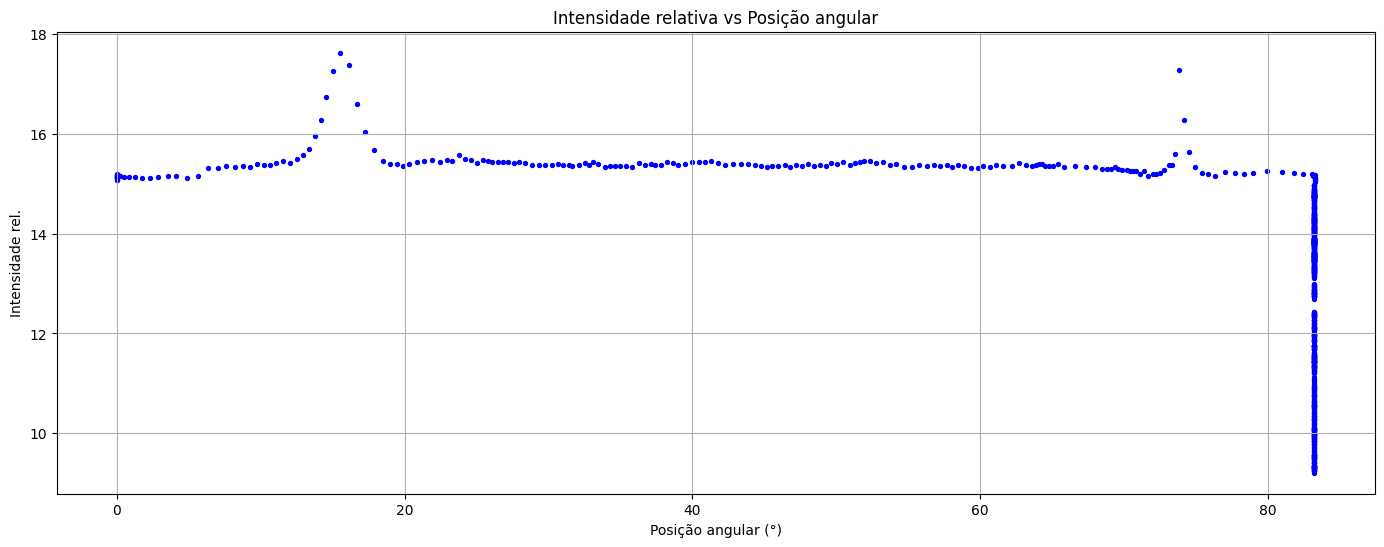

In [31]:
corrida10_limpa = ler_limpar_visualizar('experimental_data/corrida10.txt')

In [32]:
def filtrar_transformar(corrida, angulo_min=0, angulo_max=360, intensidade_min=0, intensidade_max=100, visualizar=False):
    corrida_filtrada = dominio(corrida, angulo_min, angulo_max, intensidade_min, intensidade_max, visualizar=visualizar)
    corrida_transformada = transformacao_de_eixo(corrida_filtrada, visualizar=visualizar)
    return corrida_transformada

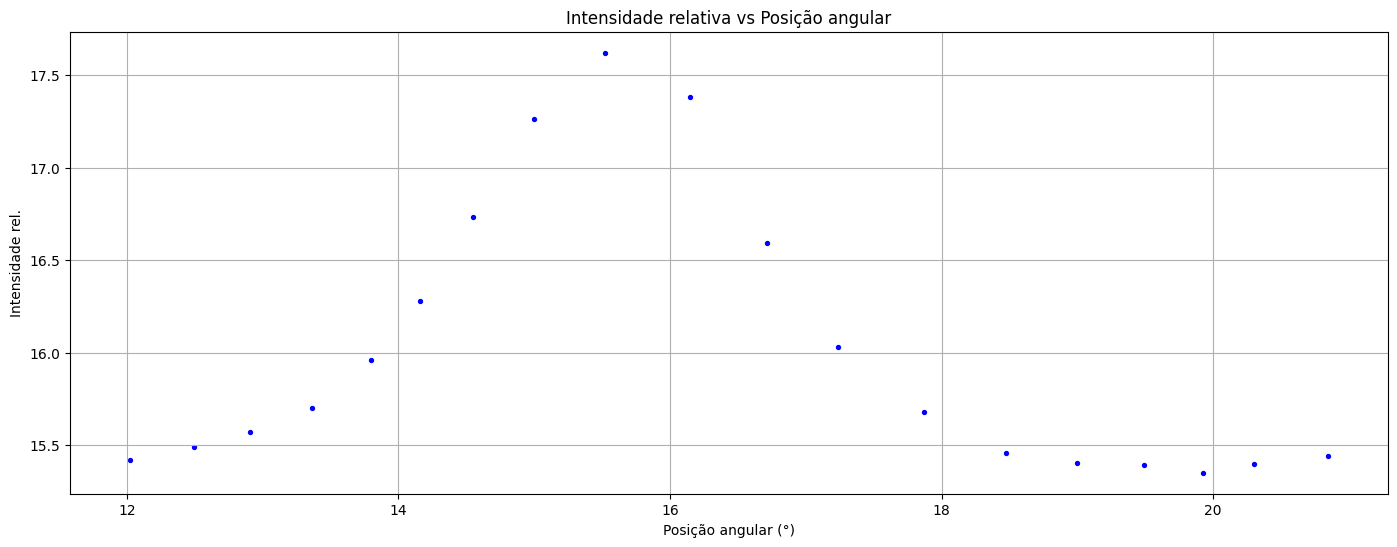

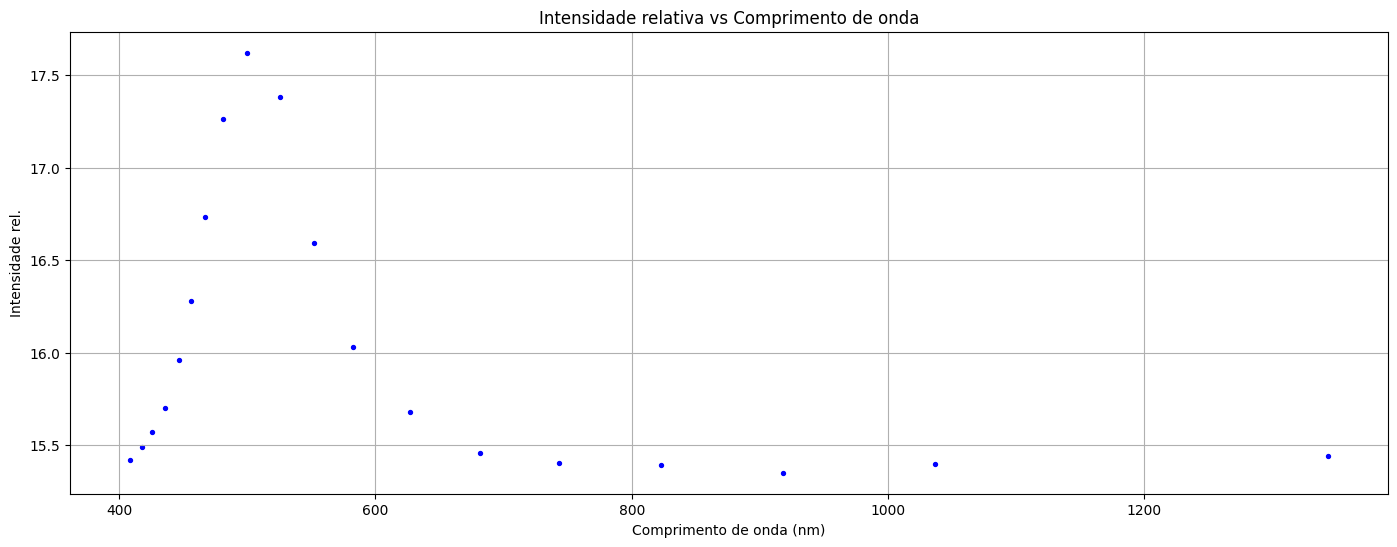

In [33]:
corrida10_transformada = filtrar_transformar(corrida10_limpa, angulo_min=12, angulo_max=21, intensidade_min=14, visualizar=True)

In [34]:
corrida10_final = corrida10_transformada.copy()
corrida10_final["Intensidade_rel_(%)"] += -corrida10_transformada["Intensidade_rel_(%)"].min()

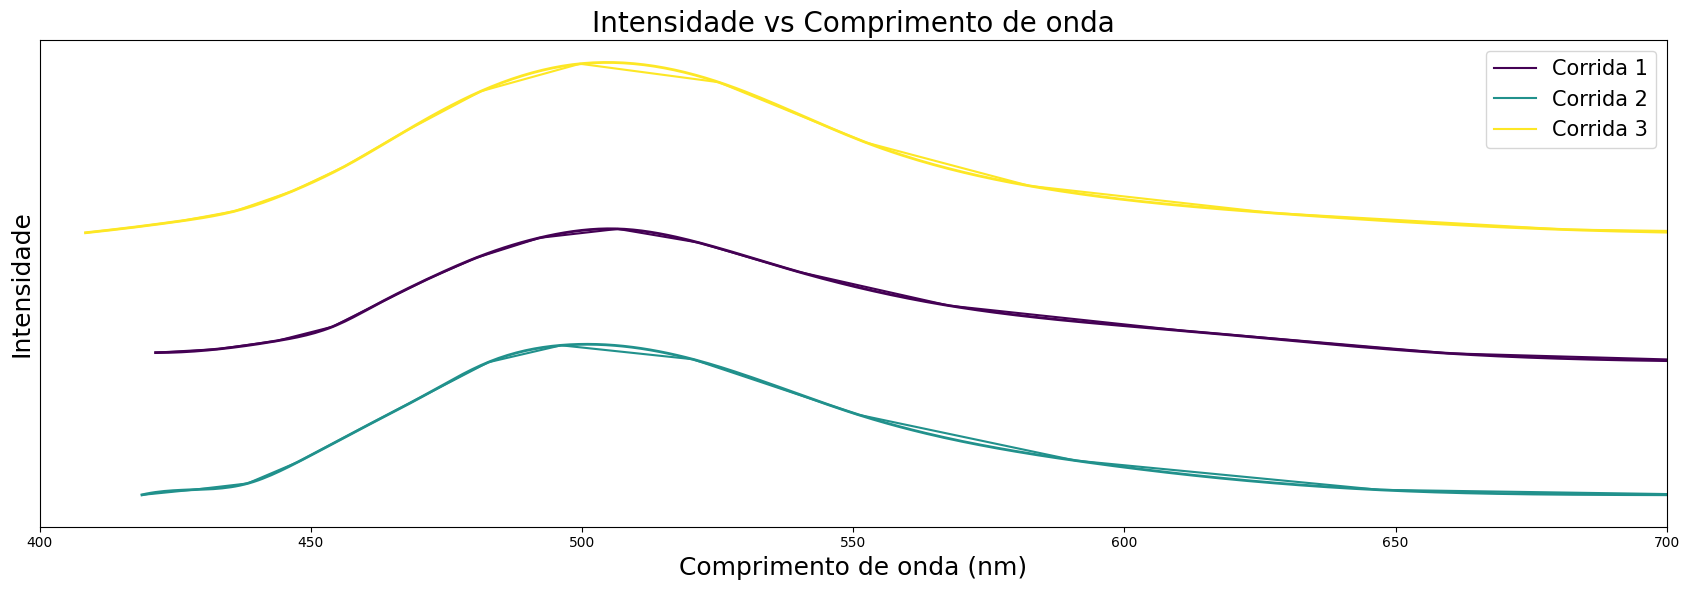

In [35]:
lei_de_plank_varias([corrida8_transformada, corrida9_transformada, corrida10_transformada], lim_inferior=400, lim_superior=700, spline=True)

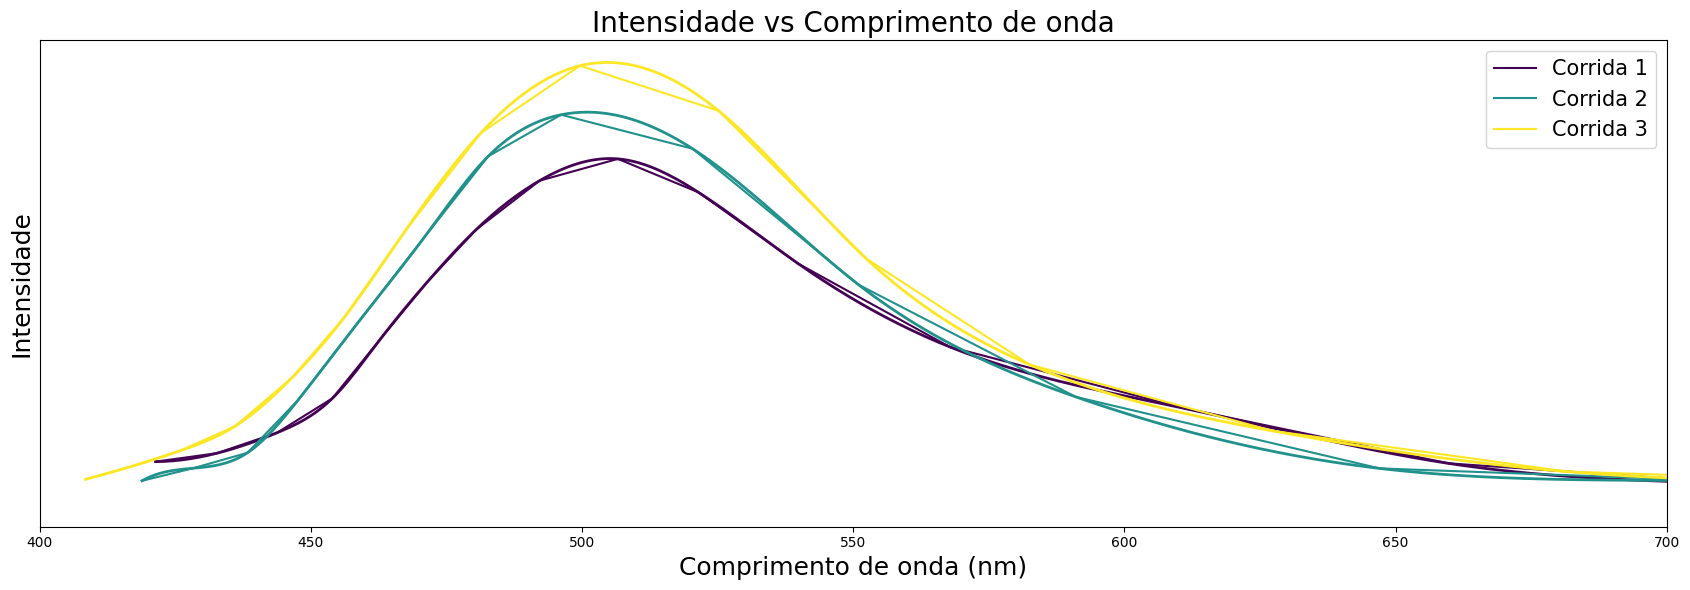

In [36]:
lei_de_plank_varias([corrida8_final, corrida9_final, corrida10_final], lim_inferior=400, lim_superior=700, spline=True,save_fig=True, nome_fig="lei_de_plank_1.png")